# BERTopic Hyperparameter Tuning Sandbox (FastAPI-Aligned)

Notebook ini dibuat sebagai sandbox eksperimen untuk tuning BERTopic agar hasil notebook konsisten dengan flow FastAPI/Laravel.

Tujuan utama:
- Menyamakan flow preprocessing, embedding, training, dan evaluasi dengan FastAPI.
- Menjalankan loop kombinasi parameter UMAP dan HDBSCAN secara otomatis.
- Mencari kombinasi parameter yang memberi topik lebih kaya tanpa menurunkan kualitas metrik (coherence c_v dan topic diversity).
- Menghasilkan payload parameter yang siap dijadikan referensi pengisian form pengaturan BERTopic di dashboard Laravel.

## FastAPI flow yang disamakan

Flow di notebook ini mengikuti alur FastAPI:
1. Data cleaning: drop abstract null, dedup exact abstract, filter year 2018-2026.
2. Preprocessing teks: `TextPreprocessor.preprocess_dataframe(...)` (sama dengan preprocessing job manager).
3. Embedding: IndoSBERT `denaya/indoSBERT-large` via `BERTopicTrainer.compute_embeddings(...)`.
4. Training: `BERTopicTrainer.train(...)` (UMAP -> HDBSCAN -> c-TF-IDF -> MMR -> reduce outliers).
5. Evaluasi: `TopicEvaluator.evaluate_bertopic(...)` untuk coherence c_v, topic diversity, score_cv_td, dan outlier rate.

In [2]:
from __future__ import annotations

import copy
import hashlib
import itertools
import json
import sys
import time
import traceback
from pathlib import Path
from typing import Any, Dict, Optional

import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "fastapi").exists():
    if (REPO_ROOT.parent / "fastapi").exists():
        REPO_ROOT = REPO_ROOT.parent
    else:
        raise RuntimeError(
            "Notebook harus dijalankan dari root repo atau folder analysis yang punya sibling folder fastapi."
        )

FASTAPI_ROOT = REPO_ROOT / "fastapi"
if str(FASTAPI_ROOT) not in sys.path:
    sys.path.insert(0, str(FASTAPI_ROOT))

from app.core.config import bertopic_settings, hdbscan_settings, lda_settings, umap_settings
from app.core.database import get_engine
from app.ml.bertopic_trainer import BERTopicTrainer
from app.ml.evaluator import TopicEvaluator
from app.ml.lda_trainer import LDATrainer
from app.models.schemas import BERTopicHyperparameters
from app.models.schemas import HDBSCANHyperparameters, LDAHyperparameters, UMAPHyperparameters
from app.services.preprocessing import TextPreprocessor

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 140)

print(f"REPO_ROOT: {REPO_ROOT}")
print(f"FASTAPI_ROOT: {FASTAPI_ROOT}")

REPO_ROOT: /home/galih/MySkripsi/- Aplikasi/my-skripsi
FASTAPI_ROOT: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi


In [19]:
# =========================================
# Konfigurasi eksperimen
# =========================================
CSV_PATH = REPO_ROOT / "analysis" / "data" / "data-skripsi-20260409-092012 new.csv"
YEAR_MIN = 2018
YEAR_MAX = 2026
RUN_DTA_DURING_TUNING = False  # DTA dimatikan saat loop tuning agar runtime cepat
RUN_DTA_AFTER_BEST = True  # DTA dijalankan sekali setelah best parameter didapat
TOP_K = 15
MAX_TRIALS = None  # isi integer kalau ingin batasi trial, mis. 30
FORCE_RECOMPUTE_EMBEDDINGS = False  # True jika ingin paksa hitung embedding ulang

OUTPUT_DIR = REPO_ROOT / "analysis" / "output" / "bertopic_tuning"
STEP_OUTPUT_DIR = OUTPUT_DIR / "step_tables"
EMBEDDING_CACHE_DIR = OUTPUT_DIR / "embedding_cache"
RUN_STAMP = time.strftime("%Y%m%d-%H%M%S")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
STEP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EMBEDDING_CACHE_DIR.mkdir(parents=True, exist_ok=True)

if not CSV_PATH.exists():
    candidates = sorted((REPO_ROOT / "analysis" / "data").glob("data-skripsi-*.csv"))
    if not candidates:
        raise FileNotFoundError("Tidak ada file data-skripsi-*.csv di analysis/data")
    CSV_PATH = candidates[-1]

# Grid fokus (tepat 16 kombinasi):
# - Dorong jumlah topik ke kisaran 5-6 tanpa ubah flow backend.
# - Tetap jaga runtime ringan untuk iterasi cepat.
PARAM_GRID = {
    "umap_n_neighbors": [15, 20],
    "umap_n_components": [5, 8],
    "umap_min_dist": [0.0],
    "hdbscan_min_cluster_size": [5, 6],
    "hdbscan_min_samples": [1, 2],
    "min_topic_size": [6],
}

print(f"CSV_PATH: {CSV_PATH}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print(f"STEP_OUTPUT_DIR: {STEP_OUTPUT_DIR}")
print(f"EMBEDDING_CACHE_DIR: {EMBEDDING_CACHE_DIR}")
print(f"RUN_STAMP: {RUN_STAMP}")
print(f"RUN_DTA_DURING_TUNING: {RUN_DTA_DURING_TUNING}")
print(f"RUN_DTA_AFTER_BEST: {RUN_DTA_AFTER_BEST}")
print(f"FORCE_RECOMPUTE_EMBEDDINGS: {FORCE_RECOMPUTE_EMBEDDINGS}")
total_trials = int(np.prod([len(v) for v in PARAM_GRID.values()]))
print(f"Total kombinasi default: {total_trials} (target: 16)")

CSV_PATH: /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/data/data-skripsi-20260409-092012 new.csv
OUTPUT_DIR: /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning
STEP_OUTPUT_DIR: /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/step_tables
EMBEDDING_CACHE_DIR: /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/embedding_cache
RUN_STAMP: 20260409-233613
RUN_DTA_DURING_TUNING: False
RUN_DTA_AFTER_BEST: True
FORCE_RECOMPUTE_EMBEDDINGS: False
Total kombinasi default: 16 (target: 16)


In [4]:
# =========================================
# Helper: parameter dan loader data
# =========================================
def get_fastapi_runtime_defaults() -> Dict[str, Any]:
    """Bangun default params sesuai runtime FastAPI (config + schema)."""
    defaults = BERTopicHyperparameters(
        embedding_model=bertopic_settings.BERTOPIC_EMBEDDING_MODEL,
        min_topic_size=bertopic_settings.BERTOPIC_MIN_TOPIC_SIZE,
        nr_topics=bertopic_settings.get_nr_topics(),
        top_n_words=bertopic_settings.BERTOPIC_TOP_N_WORDS,
        embedding_batch_size=bertopic_settings.BERTOPIC_EMBEDDING_BATCH_SIZE,
        seed=bertopic_settings.BERTOPIC_SEED,
        umap_params=UMAPHyperparameters(
            n_neighbors=umap_settings.UMAP_N_NEIGHBORS,
            n_components=umap_settings.UMAP_N_COMPONENTS,
            min_dist=umap_settings.UMAP_MIN_DIST,
            metric=umap_settings.UMAP_METRIC,
            random_state=umap_settings.UMAP_RANDOM_STATE,
        ),
        hdbscan_params=HDBSCANHyperparameters(
            min_cluster_size=hdbscan_settings.HDBSCAN_MIN_CLUSTER_SIZE,
            min_samples=hdbscan_settings.HDBSCAN_MIN_SAMPLES,
            metric=hdbscan_settings.HDBSCAN_METRIC,
            cluster_selection_method=hdbscan_settings.HDBSCAN_CLUSTER_SELECTION_METHOD,
        ),
    )
    return defaults.model_dump()


def _parse_json_maybe(value: Any) -> Optional[Dict[str, Any]]:
    if value is None:
        return None
    if isinstance(value, dict):
        return value
    if isinstance(value, (bytes, bytearray)):
        value = value.decode("utf-8", errors="ignore")
    if isinstance(value, str):
        text = value.strip()
        if text == "" or text.lower() in {"null", "none"}:
            return None
        try:
            parsed = json.loads(text)
            return parsed if isinstance(parsed, dict) else None
        except json.JSONDecodeError:
            return None
    return None


def load_latest_laravel_compact_params() -> Optional[Dict[str, Any]]:
    """Ambil snapshot parameter compact terbaru dari DB Laravel (jika ada)."""
    engine = get_engine()
    candidate_queries = [
        "SELECT bertopic_params FROM topic_model_settings WHERE bertopic_params IS NOT NULL ORDER BY updated_at DESC, id DESC LIMIT 1",
        "SELECT bertopic_params FROM topic_model_runs WHERE bertopic_params IS NOT NULL ORDER BY updated_at DESC, id DESC LIMIT 1",
    ]

    for query in candidate_queries:
        try:
            df = pd.read_sql(query, con=engine)
        except Exception:
            continue

        if df.empty:
            continue

        parsed = _parse_json_maybe(df.iloc[0]["bertopic_params"])
        if parsed:
            return parsed

    return None


def apply_compact_params_to_full(
    full_params: Dict[str, Any],
    compact_params: Optional[Dict[str, Any]],
) -> Dict[str, Any]:
    """Merge param compact Laravel ke full param BERTopic agar eksperimen mulai dari baseline web saat ini."""
    merged = copy.deepcopy(full_params)

    if not compact_params:
        return merged

    for key in ["min_topic_size", "nr_topics", "top_n_words", "n_gram_range"]:
        if key in compact_params and compact_params[key] is not None:
            merged[key] = compact_params[key]

    umap = compact_params.get("umap_params", {})
    if isinstance(umap, dict):
        for key in ["n_neighbors", "n_components", "metric"]:
            if key in umap and umap[key] is not None:
                merged["umap_params"][key] = umap[key]

    hdbscan = compact_params.get("hdbscan_params", {})
    if isinstance(hdbscan, dict):
        for key in ["min_cluster_size", "min_samples", "metric"]:
            if key in hdbscan:
                merged["hdbscan_params"][key] = hdbscan[key]

    return merged


def load_export_csv(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    rename_map = {
        "ID": "id",
        "Judul": "title",
        "Abstrak": "abstract",
        "Kesimpulan": "conclusion",
        "Tahun": "year",
        "Penulis": "author",
        "URL": "url",
        "Tanggal Deposit": "deposit_date",
        "Tanggal Modifikasi": "modified_date",
        "Sumber Kesimpulan": "conclusion_source",
        "Kata Kunci": "keywords",
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

    if "id" not in df.columns:
        df["id"] = np.arange(1, len(df) + 1, dtype=int)

    for col in ["title", "abstract", "conclusion", "year"]:
        if col not in df.columns:
            df[col] = None

    df["row_order"] = np.arange(1, len(df) + 1, dtype=int)
    return df


def clean_like_fastapi(df: pd.DataFrame, year_min: int, year_max: int) -> tuple[pd.DataFrame, Dict[str, int]]:
    """Mirror cleaning dari preprocessing_job_manager FastAPI."""
    work = df.copy()

    raw_total = len(work)
    work = work.dropna(subset=["abstract"])
    after_dropna = len(work)

    dup_mask = work.duplicated(subset=["abstract"], keep="first")
    work = work.loc[~dup_mask]
    after_dedup = len(work)

    year_numeric = pd.to_numeric(work["year"], errors="coerce")
    in_range = year_numeric.between(year_min, year_max)
    work = work.loc[in_range].copy()
    work["year"] = year_numeric.loc[in_range].astype(int).values
    after_year = len(work)

    work = work.reset_index(drop=True)

    stats = {
        "raw_total": int(raw_total),
        "dropna_abstract": int(raw_total - after_dropna),
        "duplicate_abstract": int(after_dropna - after_dedup),
        "year_out_of_range": int(after_dedup - after_year),
        "clean_total": int(after_year),
    }
    return work, stats


def preprocess_like_fastapi(df: pd.DataFrame) -> pd.DataFrame:
    preprocessor = TextPreprocessor(
        remove_stopwords=True,
        use_stemming=True,
        min_word_length=3,
        language="indonesian",
    )

    return preprocessor.preprocess_dataframe(
        df,
        text_column="abstract",
        title_column="title",
        conclusion_column="conclusion",
    )


def save_step_csv(df: pd.DataFrame, step_name: str) -> Path:
    step_path = STEP_OUTPUT_DIR / f"{step_name}_{RUN_STAMP}.csv"
    df.to_csv(step_path, index=False)
    return step_path


def display_step_table(df: pd.DataFrame, title: str, preview_rows: int = 10) -> None:
    print(f"\n{title}")
    display(df.head(preview_rows))


def build_embedding_cache_key(documents: list[str], embedding_model: str) -> str:
    """Build stable cache key dari isi dokumen + nama model embedding."""
    hasher = hashlib.sha256()
    hasher.update(embedding_model.encode("utf-8"))
    hasher.update(str(len(documents)).encode("utf-8"))
    for doc in documents:
        hasher.update(doc.encode("utf-8", errors="ignore"))
        hasher.update(b"\x00")
    return hasher.hexdigest()[:20]


def load_or_compute_shared_embeddings(
    documents: list[str],
    params_obj: BERTopicHyperparameters,
    force_recompute: bool = False,
) -> tuple[np.ndarray, Path, bool]:
    """Load embeddings dari cache jika ada; kalau tidak ada baru compute lalu simpan."""
    cache_key = build_embedding_cache_key(documents, params_obj.embedding_model)
    embedding_path = EMBEDDING_CACHE_DIR / f"embeddings_{cache_key}.npy"
    metadata_path = EMBEDDING_CACHE_DIR / f"embeddings_{cache_key}.json"

    if embedding_path.exists() and not force_recompute:
        cached_embeddings = np.load(embedding_path)
        if cached_embeddings.shape[0] == len(documents):
            return cached_embeddings, embedding_path, True
        print("Cache embedding ditemukan tapi jumlah baris tidak cocok. Akan compute ulang.")

    embedding_runner = BERTopicTrainer(params=params_obj)
    computed_embeddings = embedding_runner.compute_embeddings(documents)
    np.save(embedding_path, computed_embeddings)

    metadata = {
        "cache_key": cache_key,
        "embedding_model": params_obj.embedding_model,
        "num_documents": int(len(documents)),
        "embedding_shape": [int(computed_embeddings.shape[0]), int(computed_embeddings.shape[1])],
        "csv_path": str(CSV_PATH),
        "year_range": [YEAR_MIN, YEAR_MAX],
        "saved_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    }
    with open(metadata_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2, ensure_ascii=False)

    return computed_embeddings, embedding_path, False

In [5]:
# =========================================
# Load + preprocess dataset (FastAPI style)
# =========================================
raw_df = load_export_csv(CSV_PATH)
clean_df, cleaning_stats = clean_like_fastapi(raw_df, year_min=YEAR_MIN, year_max=YEAR_MAX)
prep_df = preprocess_like_fastapi(clean_df)

documents = prep_df["cleaned_text"].tolist()
years = prep_df["year"].astype(int).tolist()

if not years:
    raise RuntimeError("Dataset kosong setelah cleaning/preprocessing. Cek file input atau filter tahun.")

cleaning_summary_df = pd.DataFrame(
    [{"metric": k, "value": v} for k, v in cleaning_stats.items()]
)

year_distribution_df = (
    prep_df.groupby("year", as_index=False)
    .size()
    .rename(columns={"size": "doc_count"})
    .sort_values("year")
    .reset_index(drop=True)
)

preprocess_preview_df = prep_df[
    ["id", "year", "title", "cleaned_text", "processed_text"]
].head(30).copy()

cleaning_summary_path = save_step_csv(cleaning_summary_df, "step01_cleaning_summary")
year_distribution_path = save_step_csv(year_distribution_df, "step02_year_distribution")
preprocess_preview_path = save_step_csv(preprocess_preview_df, "step03_preprocess_preview")

print(f"Total dokumen final untuk BERTopic: {len(documents)}")
print(f"Year min-max final: {min(years)}-{max(years)}")
print("CSV step tersimpan:")
print(f"- {cleaning_summary_path}")
print(f"- {year_distribution_path}")
print(f"- {preprocess_preview_path}")

display_step_table(cleaning_summary_df, "Ringkasan cleaning")
display_step_table(year_distribution_df, "Distribusi dokumen per tahun")
display_step_table(preprocess_preview_df, "Preview hasil preprocessing", preview_rows=10)

2026-04-09 21:20:06.626 | INFO     | app.services.preprocessing:preprocess_dataframe:161 - Preprocessing 473 documents (dual pipeline)...
2026-04-09 21:20:06.627 | INFO     | app.services.preprocessing:preprocess_dataframe:175 -   Building combined_text (title + abstract + optional conclusion)...
2026-04-09 21:20:06.759 | INFO     | app.services.preprocessing:preprocess_dataframe:181 -   [BERTopic pipeline] Soft clean (no stopword removal, no stemming)...
2026-04-09 21:20:06.900 | INFO     | app.services.preprocessing:preprocess_dataframe:184 -   [LDA pipeline] Full clean + stopword removal + stemming...
2026-04-09 21:25:06.090 | INFO     | app.services.preprocessing:preprocess_dataframe:200 - Preprocessing complete. 473 documents remaining.
2026-04-09 21:25:06.104 | INFO     | app.services.preprocessing:preprocess_dataframe:201 -   cleaned_text avg words: 285.1
2026-04-09 21:25:06.115 | INFO     | app.services.preprocessing:preprocess_dataframe:204 -   processed_text avg words: 160.6


Total dokumen final untuk BERTopic: 473
Year min-max final: 2018-2026
CSV step tersimpan:
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/step_tables/step01_cleaning_summary_20260409-212006.csv
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/step_tables/step02_year_distribution_20260409-212006.csv
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/step_tables/step03_preprocess_preview_20260409-212006.csv

Ringkasan cleaning


,metric,value
0,raw_total,474
1,dropna_abstract,0
2,duplicate_abstract,1
3,year_out_of_range,0
4,clean_total,473



Distribusi dokumen per tahun


,year,doc_count
0,2018,47
1,2019,45
2,2020,25
3,2021,50
4,2022,52
5,2023,59
6,2024,87
7,2025,85
8,2026,23



Preview hasil preprocessing


,id,year,title,cleaned_text,processed_text
0,1,2026,"Perbandingan Metode Grid Search, Random Search, dan Bayesian Optimization dalam Optimasi Hyperparameter Model BERT untuk Analisis Sentim...","perbandingan metode grid search, random search, dan bayesian optimization dalam optimasi hyperparameter model bert untuk analisis sentim...",banding grid search random search bayesian optimization optimasi hyperparameter model bert analisis sentimen platform website coretax la...
1,2,2026,"Klasterisasi Produktivitas Pertanian di Kabupaten Batang Berdasarkan Luas Lahan, Hasil Panen, dan Penggunaan Pupuk Menggunakan K-Medoids...","klasterisasi produktivitas pertanian di kabupaten batang berdasarkan luas lahan, hasil panen, dan penggunaan pupuk menggunakan k-medoids...",klasterisasi produktivitas tani kabupaten batang dasar luas lahan panen guna pupuk medoids bas website produktivitas tani padi aspek duk...
2,3,2026,Implementasi Algoritma Holt-Winters Exponential Smoothing Untuk Prediksi Jumlah Wisatawan Objek Wisata Owabong Waterpark Purbalingga Ber...,implementasi algoritma holt-winters exponential smoothing untuk prediksi jumlah wisatawan objek wisata owabong waterpark purbalingga ber...,implementasi algoritma holt winters exponential smoothing prediksi wisatawan objek wisata owabong waterpark purbalingga bas visualisasi ...
3,4,2026,Pengembangan Aplikasi Text Mining untuk Mengekstraksi Informasi Poin Penting menggunakan Algoritma Support Vector Machine,pengembangan aplikasi text mining untuk mengekstraksi informasi poin penting menggunakan algoritma support vector machine. kebiasaan mas...,kembang aplikasi text mining ekstraksi informasi poin algoritma support vector machine biasa masyarakat indonesia cenderung baca judul b...
4,5,2026,Implementasi LSTM Untuk Prediksi Konsumsi Kalori Harian Berdasarkan Data Neraca Bahan Makanan Kementerian Pertanian,implementasi lstm untuk prediksi konsumsi kalori harian berdasarkan data neraca bahan makanan kementerian pertanian. ketahanan pangan me...,implementasi lstm prediksi konsumsi kalori hari dasar neraca bahan makan menteri tani tahan pangan isu kritis indonesia tempat peringkat...
5,6,2026,Analisis Perbandingan Performa Firebase Firestore dan Supabase PostgreSQL Aplikasi Inventaris Menggunakan Flutter Berbasis Mobile,analisis perbandingan performa firebase firestore dan supabase postgresql aplikasi inventaris menggunakan flutter berbasis mobile. keter...,analisis banding performa firebase firestore supabase postgresql aplikasi inventaris flutter bas mobile batas inventaris dukung akses mo...
6,7,2026,Implementasi Algoritma Dijkstra dalam Sistem Informasi Geografis Pemetaan Lokasi Pengumpulan Sampah Organik untuk Kelompok Nasabah PNM d...,implementasi algoritma dijkstra dalam sistem informasi geografis pemetaan lokasi pengumpulan sampah organik untuk kelompok nasabah pnm d...,implementasi algoritma dijkstra informasi geografis meta lokasi kumpul sampah organik kelompok nasabah pnm banyumas tingkat volume sampa...
7,8,2026,Klasterisasi Data Pemohon Paspor Berdasarkan Karakteristik Pemohon Menggunakan Algoritma K-Prototypes Berbasis Aplikasi Website di Kanto...,klasterisasi data pemohon paspor berdasarkan karakteristik pemohon menggunakan algoritma k-prototypes berbasis aplikasi website di kanto...,klasterisasi mohon paspor dasar karakteristik mohon algoritma prototypes bas aplikasi website kantor imigrasi cilacap dasar mohon paspor...
8,9,2026,Implementasi Sistem Pendukung Keputusan Dalam Penentuan Jalur Pendakian Gunung Menggunakan Fuzzy Multi Atribute Decision Making (Fuzzy M...,implementasi sistem pendukung keputusan dalam penentuan jalur pendakian gunung menggunakan fuzzy multi atribute decision making (fuzzy m...,implementasi dukung putus tentu jalur daki gunung fuzzy multi atribute decision making fuzzy madm topsis studi muncak indonesia milik ag...
9,10,2026,Perbandingan React Native dan Flutter dalam Pengembangan Sistem Aplikasi Kasir Resto,perbandingan react native dan flutter dalam p

In [6]:
# =========================================
# Helper: trial builder + training-evaluation
# =========================================
def build_trial_grid(param_grid: Dict[str, list[Any]]) -> list[Dict[str, Any]]:
    keys = list(param_grid.keys())
    values = [param_grid[k] for k in keys]
    return [dict(zip(keys, combo)) for combo in itertools.product(*values)]


def build_trial_param_dict(base_params: Dict[str, Any], trial: Dict[str, Any]) -> Dict[str, Any]:
    params = copy.deepcopy(base_params)

    params["min_topic_size"] = int(trial["min_topic_size"])
    params["umap_params"]["n_neighbors"] = int(trial["umap_n_neighbors"])
    params["umap_params"]["n_components"] = int(trial["umap_n_components"])
    params["umap_params"]["min_dist"] = float(trial["umap_min_dist"])

    params["hdbscan_params"]["min_cluster_size"] = int(trial["hdbscan_min_cluster_size"])
    ms = trial["hdbscan_min_samples"]
    params["hdbscan_params"]["min_samples"] = None if pd.isna(ms) else int(ms)

    return params


def evaluate_trained_model(
    trainer: BERTopicTrainer,
    documents_input: list[str],
    params_obj: BERTopicHyperparameters,
) -> Dict[str, Any]:
    evaluator = TopicEvaluator()
    return evaluator.evaluate_bertopic(
        model=trainer.model,
        documents=documents_input,
        topics=trainer.topics,
        vectorizer_model=trainer.vectorizer_model,
        coherence_type=params_obj.coherence_type,
        coherence_tokenization=params_obj.coherence_tokenization,
        coherence_dict_no_below=params_obj.coherence_dict_no_below,
        coherence_dict_no_above=params_obj.coherence_dict_no_above,
        top_n_words=params_obj.top_n_words,
    )


def build_laravel_payload(best_row: pd.Series, base_params: Dict[str, Any]) -> Dict[str, Any]:
    return {
        "min_topic_size": int(best_row["min_topic_size"]),
        "nr_topics": base_params.get("nr_topics", "auto"),
        "top_n_words": int(base_params.get("top_n_words", 10)),
        "n_gram_range": [
            int(base_params.get("n_gram_range", [1, 2])[0]),
            int(base_params.get("n_gram_range", [1, 2])[1]),
        ],
        "umap_params": {
            "n_neighbors": int(best_row["umap_n_neighbors"]),
            "n_components": int(best_row["umap_n_components"]),
            "metric": str(base_params.get("umap_params", {}).get("metric", "cosine")),
        },
        "hdbscan_params": {
            "min_cluster_size": int(best_row["hdbscan_min_cluster_size"]),
            "min_samples": None if pd.isna(best_row["hdbscan_min_samples"]) else int(best_row["hdbscan_min_samples"]),
            "metric": str(base_params.get("hdbscan_params", {}).get("metric", "euclidean")),
        },
    }

In [7]:
# =========================================
# Siapkan baseline params + shared embeddings
# =========================================
base_params = get_fastapi_runtime_defaults()
compact_params = load_latest_laravel_compact_params()
base_params = apply_compact_params_to_full(base_params, compact_params)

print("Compact params dari Laravel ada:", compact_params is not None)
if compact_params is not None:
    print(json.dumps(compact_params, indent=2, ensure_ascii=False))

base_param_obj = BERTopicHyperparameters(**base_params)
print("Baseline params dipakai untuk eksperimen:")
print(json.dumps(base_param_obj.model_dump(), indent=2, ensure_ascii=False))

# Optimasi runtime: embeddings dicache ke file agar rerun berikutnya tidak encode ulang.
shared_embeddings, embedding_cache_path, embeddings_from_cache = load_or_compute_shared_embeddings(
    documents,
    base_param_obj,
    force_recompute=FORCE_RECOMPUTE_EMBEDDINGS,
)
print("Shared embeddings shape:", shared_embeddings.shape)
print("Embeddings loaded from cache:", embeddings_from_cache)
print("Embedding cache file:", embedding_cache_path)

baseline_param_table_df = (
    pd.json_normalize(base_param_obj.model_dump(), sep=".")
    .T.reset_index()
    .rename(columns={"index": "parameter", 0: "value"})
)

embedding_summary_df = pd.DataFrame([
    {"metric": "num_documents", "value": int(len(documents))},
    {"metric": "embedding_rows", "value": int(shared_embeddings.shape[0])},
    {"metric": "embedding_dims", "value": int(shared_embeddings.shape[1])},
    {"metric": "year_min", "value": int(min(years))},
    {"metric": "year_max", "value": int(max(years))},
    {"metric": "embeddings_from_cache", "value": bool(embeddings_from_cache)},
    {"metric": "embedding_cache_file", "value": str(embedding_cache_path)},
])

baseline_param_path = save_step_csv(baseline_param_table_df, "step04_bertopic_baseline_params")
embedding_summary_path = save_step_csv(embedding_summary_df, "step05_embedding_summary")

print("CSV step tersimpan:")
print(f"- {baseline_param_path}")
print(f"- {embedding_summary_path}")

display_step_table(baseline_param_table_df, "Tabel baseline parameter BERTopic", preview_rows=30)
display_step_table(embedding_summary_df, "Ringkasan embedding")

Compact params dari Laravel ada: False
Baseline params dipakai untuk eksperimen:
{
  "embedding_model": "denaya/indoSBERT-large",
  "min_topic_size": 10,
  "nr_topics": "auto",
  "top_n_words": 10,
  "n_gram_range": [
    1,
    2
  ],
  "vectorizer_min_df": 2,
  "vectorizer_max_df": 0.95,
  "vectorizer_token_pattern": "(?u)\\b\\w{3,}\\b",
  "vectorizer_fallback_min_df": 1,
  "vectorizer_fallback_max_df": 1.0,
  "coherence_type": "c_v",
  "coherence_tokenization": "vectorizer",
  "coherence_dict_no_below": 3,
  "coherence_dict_no_above": 0.95,
  "reduce_outliers": true,
  "reduce_outliers_threshold_ctfidf": 0.1,
  "reduce_outliers_use_distributions": true,
  "reduce_outliers_threshold_distributions": 0.05,
  "use_mmr_representation": true,
  "mmr_diversity": 0.3,
  "embedding_batch_size": 16,
  "seed": 42,
  "umap_params": {
    "n_neighbors": 15,
    "n_components": 5,
    "min_dist": 0.0,
    "metric": "cosine",
    "random_state": 42
  },
  "hdbscan_params": {
    "min_cluster_size"

,parameter,value
0,embedding_model,denaya/indoSBERT-large
1,min_topic_size,10
2,nr_topics,auto
3,top_n_words,10
4,n_gram_range,"[1, 2]"
5,vectorizer_min_df,2
6,vectorizer_max_df,0.95
7,vectorizer_token_pattern,"(?u)\b\w{3,}\b"
8,vectorizer_fallback_min_df,1
9,vectorizer_fallback_max_df,1.0



Ringkasan embedding


,metric,value
0,num_documents,473
1,embedding_rows,473
2,embedding_dims,256
3,year_min,2018
4,year_max,2026
5,embeddings_from_cache,True
6,embedding_cache_file,/home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/embedding_cache/embeddings_33d03169c19c1b7d08ff.npy


In [8]:
# =========================================
# Loop tuning UMAP + HDBSCAN
# =========================================
trial_grid = build_trial_grid(PARAM_GRID)
if MAX_TRIALS is not None:
    trial_grid = trial_grid[: int(MAX_TRIALS)]

print(f"Total trial yang akan dijalankan: {len(trial_grid)}")

results = []

for i, trial in enumerate(trial_grid, start=1):
    started = time.time()

    row = {
        "trial_no": i,
        "umap_n_neighbors": trial["umap_n_neighbors"],
        "umap_n_components": trial["umap_n_components"],
        "umap_min_dist": trial["umap_min_dist"],
        "hdbscan_min_cluster_size": trial["hdbscan_min_cluster_size"],
        "hdbscan_min_samples": trial["hdbscan_min_samples"],
        "min_topic_size": trial["min_topic_size"],
    }

    try:
        trial_param_dict = build_trial_param_dict(base_params, trial)
        trial_param_obj = BERTopicHyperparameters(**trial_param_dict)

        trainer = BERTopicTrainer(params=trial_param_obj)
        train_result = trainer.train(
            documents=documents,
            embeddings=shared_embeddings,
            timestamps=years if RUN_DTA_DURING_TUNING else None,
        )

        metrics = evaluate_trained_model(
            trainer=trainer,
            documents_input=documents,
            params_obj=trial_param_obj,
        )

        row.update({
            "status": "ok",
            "num_topics": int(metrics.get("num_topics", train_result.get("num_topics", 0))),
            "num_outliers": int(metrics.get("num_outliers", train_result.get("num_outliers", 0))),
            "outlier_pct": float(metrics.get("outlier_pct", 0.0)),
            "coherence_cv": float(metrics.get("coherence_cv", np.nan)),
            "topic_diversity": float(metrics.get("topic_diversity", np.nan)),
            "score": float(metrics.get("score", np.nan)),
            "score_hmean_cv_td": float(metrics.get("score_hmean_cv_td", np.nan)),
            "score_cv_td": float(metrics.get("score_cv_td", np.nan)),
            "error": None,
        })

    except Exception as exc:
        row.update({
            "status": "failed",
            "num_topics": np.nan,
            "num_outliers": np.nan,
            "outlier_pct": np.nan,
            "coherence_cv": np.nan,
            "topic_diversity": np.nan,
            "score": np.nan,
            "score_hmean_cv_td": np.nan,
            "score_cv_td": np.nan,
            "error": f"{type(exc).__name__}: {exc}",
            "traceback": traceback.format_exc(limit=2),
        })

    row["duration_sec"] = round(time.time() - started, 2)
    results.append(row)

    if i == 1 or i % 5 == 0 or i == len(trial_grid):
        ok_count = sum(r.get("status") == "ok" for r in results)
        print(f"[{i}/{len(trial_grid)}] done | ok={ok_count} | last_status={row['status']} | duration={row['duration_sec']}s")

results_df = pd.DataFrame(results)
print("Selesai tuning.")
print(results_df["status"].value_counts(dropna=False))

bertopic_trial_view_cols = [
    "trial_no",
    "status",
    "coherence_cv",
    "topic_diversity",
    "score_cv_td",
    "num_topics",
    "outlier_pct",
    "duration_sec",
    "error",
]
bertopic_trials_view_df = results_df[bertopic_trial_view_cols].copy()

bertopic_trials_full_path = save_step_csv(results_df, "step06_bertopic_trials_full")
bertopic_trials_view_path = save_step_csv(bertopic_trials_view_df, "step07_bertopic_trials_view")

print("CSV step tersimpan:")
print(f"- {bertopic_trials_full_path}")
print(f"- {bertopic_trials_view_path}")

display_step_table(bertopic_trials_view_df, "Ringkasan hasil trial BERTopic", preview_rows=15)

2026-04-09 21:25:06.376 | INFO     | app.ml.bertopic_trainer:train:359 - Starting BERTopic training on 473 documents
2026-04-09 21:25:06.377 | INFO     | app.ml.bertopic_trainer:train:360 - Embedding model: denaya/indoSBERT-large (256-dim)


Total trial yang akan dijalankan: 24


2026-04-09 21:25:07.980 | INFO     | app.ml.bertopic_trainer:train:363 - Reproducibility settings applied with seed=42
2026-04-09 21:25:07.982 | INFO     | app.ml.bertopic_trainer:_build_embedding_model:145 - Loading sentence encoder: denaya/indoSBERT-large (IndoBERT-large + Siamese Network, output: 256-dim)
2026-04-09 21:25:18.419 | INFO     | app.ml.bertopic_trainer:_build_model:293 - BERTopic model pipeline built successfully
2026-04-09 21:25:18.423 | INFO     | app.ml.bertopic_trainer:train:373 - Fitting BERTopic model (UMAP → HDBSCAN → c-TF-IDF + MMR)...
2026-04-09 21:25:18,432 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-09 21:25:30,660 - BERTopic - Dimensionality - Completed ✓
2026-04-09 21:25:30,661 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-09 21:25:30,742 - BERTopic - Cluster - Completed ✓
2026-04-09 21:25:30,743 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-0

[1/24] done | ok=1 | last_status=ok | duration=485.88s


2026-04-09 21:33:23.291 | INFO     | app.ml.bertopic_trainer:_build_model:293 - BERTopic model pipeline built successfully
2026-04-09 21:33:23.294 | INFO     | app.ml.bertopic_trainer:train:373 - Fitting BERTopic model (UMAP → HDBSCAN → c-TF-IDF + MMR)...
2026-04-09 21:33:23,299 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-09 21:33:24,419 - BERTopic - Dimensionality - Completed ✓
2026-04-09 21:33:24,423 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-09 21:33:24,464 - BERTopic - Cluster - Completed ✓
2026-04-09 21:33:24,465 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-04-09 21:34:05,866 - BERTopic - Representation - Completed ✓
2026-04-09 21:34:05,867 - BERTopic - Topic reduction - Reducing number of topics
2026-04-09 21:34:45,863 - BERTopic - Topic reduction - Reduced number of topics from 18 to 18
2026-04-09 21:34:46.034 | INFO     | app.ml.bertopic_trainer:train:390 - Ou

...

2026-04-09 21:59:35.707 | INFO     | app.ml.bertopic_trainer:_build_model:293 - BERTopic model pipeline built successfully
2026-04-09 21:59:35.709 | INFO     | app.ml.bertopic_trainer:train:373 - Fitting BERTopic model (UMAP → HDBSCAN → c-TF-IDF + MMR)...
2026-04-09 21:59:35,712 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-09 21:59:36,593 - BERTopic - Dimensionality - Completed ✓
2026-04-09 21:59:36,594 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-09 21:59:36,610 - BERTopic - Cluster - Completed ✓
2026-04-09 21:59:36,611 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-04-09 22:00:09,063 - BERTopic - Representation - Completed ✓
2026-04-09 22:00:09,064 - BERTopic - Topic reduction - Reducing number of topics
2026-04-09 22:00:42,428 - BERTopic - Topic reduction - Reduced number of topics from 13 to 13
2026-04-09 22:00:42.593 | INFO     | app.ml.bertopic_trainer:train:390 - Ou

[20/24] done | ok=20 | last_status=ok | duration=73.73s


2026-04-09 22:08:47.102 | INFO     | app.ml.bertopic_trainer:_build_model:293 - BERTopic model pipeline built successfully
2026-04-09 22:08:47.106 | INFO     | app.ml.bertopic_trainer:train:373 - Fitting BERTopic model (UMAP → HDBSCAN → c-TF-IDF + MMR)...
2026-04-09 22:08:47,115 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-09 22:08:48,038 - BERTopic - Dimensionality - Completed ✓
2026-04-09 22:08:48,039 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-09 22:08:48,057 - BERTopic - Cluster - Completed ✓
2026-04-09 22:08:48,058 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-04-09 22:09:33,852 - BERTopic - Representation - Completed ✓
2026-04-09 22:09:33,853 - BERTopic - Topic reduction - Reducing number of topics
2026-04-09 22:09:58,283 - BERTopic - Topic reduction - Reduced number of topics from 20 to 10
2026-04-09 22:09:58.429 | INFO     | app.ml.bertopic_trainer:train:390 - Ou

[24/24] done | ok=24 | last_status=ok | duration=120.66s
Selesai tuning.
status
ok    24
Name: count, dtype: int64
CSV step tersimpan:
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/step_tables/step06_bertopic_trials_full_20260409-212006.csv
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/step_tables/step07_bertopic_trials_view_20260409-212006.csv

Ringkasan hasil trial BERTopic


,trial_no,status,coherence_cv,topic_diversity,score_cv_td,num_topics,outlier_pct,duration_sec,error
0,1,ok,0.3904,0.8300,0.544260,20,0.0,485.88,None
1,2,ok,0.4085,0.9000,0.580525,17,0.0,144.14,None
2,3,ok,0.3866,0.8833,0.560445,18,0.0,147.55,None
3,4,ok,0.4320,0.8692,0.585020,13,0.0,112.11,None
4,5,ok,0.4300,0.8846,0.589110,13,0.0,113.70,None
5,6,ok,0.4110,0.9000,0.582150,13,0.0,115.24,None
6,7,ok,0.4000,0.9000,0.575000,12,0.0,110.74,None
7,8,ok,0.4028,0.8833,0.570975,12,0.0,106.82,None
8,9,ok,0.4344,0.9750,0.623610,4,0.0,79.77,None
9,10,ok,0.4301,0.9214,0.602055,14,0.0,119.88,None


In [18]:
# =========================================
# Ranking kandidat terbaik
# =========================================
success_df = results_df[results_df["status"] == "ok"].copy()
if success_df.empty:
    raise RuntimeError("Semua trial gagal. Cek kolom error/traceback pada results_df.")

# Apple-to-apple dengan LDA: keduanya pakai CV * TD (tanpa outlier penalty).
success_df["score_cv_td_apple_to_apple"] = success_df["coherence_cv"] * success_df["topic_diversity"]
success_df["rank_score"] = success_df["score_cv_td_apple_to_apple"]

ranked_df = success_df.sort_values(
    ["rank_score", "coherence_cv", "topic_diversity"],
    ascending=[False, False, False],
).reset_index(drop=True)

cols_view = [
    "trial_no",
    "umap_n_neighbors",
    "umap_n_components",
    "umap_min_dist",
    "hdbscan_min_cluster_size",
    "hdbscan_min_samples",
    "min_topic_size",
    "num_topics",
    "coherence_cv",
    "topic_diversity",
    "score_cv_td",
    "score_cv_td_apple_to_apple",
    "rank_score",
    "outlier_pct",
    "duration_sec",
]

bertopic_topk_df = ranked_df[cols_view].head(TOP_K).copy()
display(bertopic_topk_df)

best_row = ranked_df.iloc[0]
best_laravel_payload = build_laravel_payload(best_row, base_params)

bertopic_best_summary_df = pd.DataFrame([
    {"metric": "trial_no", "value": int(best_row["trial_no"])},
    {"metric": "num_topics", "value": int(best_row["num_topics"])},
    {"metric": "coherence_cv", "value": float(best_row["coherence_cv"])},
    {"metric": "topic_diversity", "value": float(best_row["topic_diversity"])},
    {"metric": "score_cv_td_backend", "value": float(best_row["score_cv_td"])},
    {"metric": "score_cv_td_apple_to_apple", "value": float(best_row["score_cv_td_apple_to_apple"])},
    {"metric": "rank_score", "value": float(best_row["rank_score"])},
    {"metric": "outlier_pct", "value": float(best_row["outlier_pct"])}
])

bertopic_topk_path = save_step_csv(bertopic_topk_df, "step08_bertopic_topk")
bertopic_best_summary_path = save_step_csv(bertopic_best_summary_df, "step09_bertopic_best_summary")

print("CSV step tersimpan:")
print(f"- {bertopic_topk_path}")
print(f"- {bertopic_best_summary_path}")

display_step_table(bertopic_best_summary_df, "Ringkasan best BERTopic")

print("Best trial (berdasarkan rank_score):")
print(best_row[cols_view].to_string())

print("\nPayload referensi untuk form Laravel (BERTopic):")
print(json.dumps(best_laravel_payload, indent=2, ensure_ascii=False))

,trial_no,umap_n_neighbors,umap_n_components,umap_min_dist,hdbscan_min_cluster_size,hdbscan_min_samples,min_topic_size,num_topics,coherence_cv,topic_diversity,score_cv_td,score_cv_td_apple_to_apple,rank_score,outlier_pct,duration_sec
0,9,30,5,0.0,8,1,8,4,0.4344,0.9750,0.623610,0.423540,0.423540,0.0,79.77
1,18,35,5,0.0,8,2,8,7,0.4460,0.9429,0.619915,0.420533,0.420533,0.0,94.67
2,23,35,8,0.0,10,1,8,12,0.4678,0.8750,0.610320,0.409325,0.409325,0.0,112.56
3,17,35,5,0.0,8,1,8,10,0.4666,0.8700,0.607790,0.405942,0.405942,0.0,110.91
4,21,35,8,0.0,8,1,8,9,0.4385,0.9222,0.607795,0.404385,0.404385,0.0,107.32
5,15,30,8,0.0,10,1,8,12,0.4249,0.9417,0.605780,0.400128,0.400128,0.0,107.76
6,10,30,5,0.0,8,2,8,14,0.4301,0.9214,0.602055,0.396294,0.396294,0.0,119.88
7,22,35,8,0.0,8,2,8,12,0.4214,0.9250,0.597660,0.389795,0.389795,0.0,115.71
8,24,35,8,0.0,10,2,8,14,0.4400,0.8786,0.593510,0.386584,0.386584,0.0,120.66
9,16,30,8,0.0,10,2,8,12,0.4131,0.9333,0.595170,0.385546,0.385546,0.0,108.24


CSV step tersimpan:
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/step_tables/step08_bertopic_topk_20260409-212006.csv
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/step_tables/step09_bertopic_best_summary_20260409-212006.csv

Ringkasan best BERTopic


,metric,value
0,trial_no,9.00000
1,num_topics,4.00000
2,coherence_cv,0.43440
3,topic_diversity,0.97500
4,score_cv_td_backend,0.62361
5,score_cv_td_apple_to_apple,0.42354
6,rank_score,0.42354
7,outlier_pct,0.00000


Best trial (berdasarkan rank_score):
trial_no                            9
umap_n_neighbors                   30
umap_n_components                   5
umap_min_dist                     0.0
hdbscan_min_cluster_size            8
hdbscan_min_samples                 1
min_topic_size                      8
num_topics                          4
coherence_cv                   0.4344
topic_diversity                 0.975
score_cv_td                   0.62361
score_cv_td_apple_to_apple    0.42354
rank_score                    0.42354
outlier_pct                       0.0
duration_sec                    79.77

Payload referensi untuk form Laravel (BERTopic):
{
  "min_topic_size": 8,
  "nr_topics": "auto",
  "top_n_words": 10,
  "n_gram_range": [
    1,
    2
  ],
  "umap_params": {
    "n_neighbors": 30,
    "n_components": 5,
    "metric": "cosine"
  },
  "hdbscan_params": {
    "min_cluster_size": 8,
    "min_samples": 1,
    "metric": "euclidean"
  }
}


In [10]:
# =========================================
# Simpan artefak eksperimen + DTA best only
# =========================================
stamp = RUN_STAMP

best_topics_over_time_df = pd.DataFrame()
best_dta_summary_df = pd.DataFrame()
best_topics_over_time_path = None
best_dta_summary_path = None

if RUN_DTA_AFTER_BEST:
    print("Menjalankan DTA sekali pada best BERTopic...")

    best_trial_for_dta = {
        "min_topic_size": int(best_row["min_topic_size"]),
        "umap_n_neighbors": int(best_row["umap_n_neighbors"]),
        "umap_n_components": int(best_row["umap_n_components"]),
        "umap_min_dist": float(best_row["umap_min_dist"]),
        "hdbscan_min_cluster_size": int(best_row["hdbscan_min_cluster_size"]),
        "hdbscan_min_samples": None if pd.isna(best_row["hdbscan_min_samples"]) else int(best_row["hdbscan_min_samples"]),
    }

    best_param_dict_for_dta = build_trial_param_dict(base_params, best_trial_for_dta)
    best_param_obj_for_dta = BERTopicHyperparameters(**best_param_dict_for_dta)

    best_trainer_dta = BERTopicTrainer(params=best_param_obj_for_dta)
    best_train_with_dta = best_trainer_dta.train(
        documents=documents,
        embeddings=shared_embeddings,
        timestamps=years,
    )

    best_topics_over_time_df = pd.DataFrame(best_train_with_dta.get("topics_over_time", []))

    if not best_topics_over_time_df.empty:
        best_topics_over_time_path = OUTPUT_DIR / f"bertopic_topics_over_time_best_{stamp}.csv"
        best_topics_over_time_df.to_csv(best_topics_over_time_path, index=False)

        best_dta_summary_df = (
            best_topics_over_time_df.groupby("Timestamp", as_index=False)
            .agg(
                num_topic_points=("Topic", "count"),
                avg_frequency=("Frequency", "mean"),
            )
            .sort_values("Timestamp")
            .reset_index(drop=True)
        )

        best_dta_summary_path = save_step_csv(
            best_dta_summary_df,
            "step10_bertopic_dta_best_summary",
        )

        print("File DTA best BERTopic:")
        print(f"- {best_topics_over_time_path}")
        print(f"- {best_dta_summary_path}")
        display_step_table(best_dta_summary_df, "Ringkasan DTA best BERTopic")
    else:
        print("DTA best BERTopic tidak menghasilkan topics_over_time.")
else:
    print("RUN_DTA_AFTER_BEST=False, DTA best BERTopic dilewati.")

results_path = OUTPUT_DIR / f"bertopic_tuning_results_{stamp}.csv"
ranked_path = OUTPUT_DIR / f"bertopic_tuning_ranked_{stamp}.csv"
payload_path = OUTPUT_DIR / f"bertopic_laravel_payload_{stamp}.json"
summary_path = OUTPUT_DIR / f"bertopic_tuning_summary_{stamp}.json"

results_df.to_csv(results_path, index=False)
ranked_df.to_csv(ranked_path, index=False)

with open(payload_path, "w", encoding="utf-8") as f:
    json.dump(best_laravel_payload, f, indent=2, ensure_ascii=False)

summary = {
    "csv_path": str(CSV_PATH),
    "year_range": [YEAR_MIN, YEAR_MAX],
    "run_dta_during_tuning": RUN_DTA_DURING_TUNING,
    "run_dta_after_best": RUN_DTA_AFTER_BEST,
    "total_trials": int(len(trial_grid)),
    "success_trials": int((results_df["status"] == "ok").sum()),
    "best_trial": {
        "trial_no": int(best_row["trial_no"]),
        "num_topics": int(best_row["num_topics"]),
        "coherence_cv": float(best_row["coherence_cv"]),
        "topic_diversity": float(best_row["topic_diversity"]),
        "score_cv_td": float(best_row["score_cv_td"]),
        "rank_score": float(best_row["rank_score"]),
    },
    "best_laravel_payload": best_laravel_payload,
}

if not best_topics_over_time_df.empty:
    summary["best_topics_over_time_rows"] = int(len(best_topics_over_time_df))

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

artifact_rows = [
    {"artifact": "bertopic_tuning_results", "path": str(results_path)},
    {"artifact": "bertopic_tuning_ranked", "path": str(ranked_path)},
    {"artifact": "bertopic_laravel_payload", "path": str(payload_path)},
    {"artifact": "bertopic_tuning_summary", "path": str(summary_path)},
]
if best_topics_over_time_path is not None:
    artifact_rows.append({"artifact": "bertopic_topics_over_time_best", "path": str(best_topics_over_time_path)})
if best_dta_summary_path is not None:
    artifact_rows.append({"artifact": "bertopic_dta_best_summary", "path": str(best_dta_summary_path)})

bertopic_artifact_manifest_df = pd.DataFrame(artifact_rows)
bertopic_artifact_manifest_path = save_step_csv(
    bertopic_artifact_manifest_df,
    "step11_bertopic_artifact_manifest",
)

print("File output berhasil disimpan:")
print(f"- {results_path}")
print(f"- {ranked_path}")
print(f"- {payload_path}")
print(f"- {summary_path}")
print(f"- {bertopic_artifact_manifest_path}")

display_step_table(bertopic_artifact_manifest_df, "Daftar artefak BERTopic")

2026-04-09 22:16:17.384 | INFO     | app.ml.bertopic_trainer:train:359 - Starting BERTopic training on 473 documents
2026-04-09 22:16:17.385 | INFO     | app.ml.bertopic_trainer:train:360 - Embedding model: denaya/indoSBERT-large (256-dim)
2026-04-09 22:16:17.389 | INFO     | app.ml.bertopic_trainer:train:363 - Reproducibility settings applied with seed=42
2026-04-09 22:16:17.389 | INFO     | app.ml.bertopic_trainer:_build_embedding_model:145 - Loading sentence encoder: denaya/indoSBERT-large (IndoBERT-large + Siamese Network, output: 256-dim)


Menjalankan DTA sekali pada best BERTopic...


2026-04-09 22:16:23.697 | INFO     | app.ml.bertopic_trainer:_build_model:293 - BERTopic model pipeline built successfully
2026-04-09 22:16:23.700 | INFO     | app.ml.bertopic_trainer:train:373 - Fitting BERTopic model (UMAP → HDBSCAN → c-TF-IDF + MMR)...
2026-04-09 22:16:23,705 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-09 22:16:24,599 - BERTopic - Dimensionality - Completed ✓
2026-04-09 22:16:24,600 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-09 22:16:24,616 - BERTopic - Cluster - Completed ✓
2026-04-09 22:16:24,617 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-04-09 22:17:12,398 - BERTopic - Representation - Completed ✓
2026-04-09 22:17:12,399 - BERTopic - Topic reduction - Reducing number of topics
2026-04-09 22:17:23,581 - BERTopic - Topic reduction - Reduced number of topics from 21 to 5
2026-04-09 22:17:23.690 | INFO     | app.ml.bertopic_trainer:train:390 - Out

File DTA best BERTopic:
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/bertopic_topics_over_time_best_20260409-212006.csv
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/step_tables/step10_bertopic_dta_best_summary_20260409-212006.csv

Ringkasan DTA best BERTopic


,Timestamp,num_topic_points,avg_frequency
0,2018,3,15.666667
1,2019,2,22.500000
2,2020,3,8.333333
3,2021,3,16.666667
4,2022,4,13.000000
5,2023,4,14.750000
6,2024,4,21.750000
7,2025,4,21.250000
8,2026,2,11.500000


File output berhasil disimpan:
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/bertopic_tuning_results_20260409-212006.csv
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/bertopic_tuning_ranked_20260409-212006.csv
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/bertopic_laravel_payload_20260409-212006.json
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/bertopic_tuning_summary_20260409-212006.json
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/step_tables/step11_bertopic_artifact_manifest_20260409-212006.csv

Daftar artefak BERTopic


,artifact,path
0,bertopic_tuning_results,/home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/bertopic_tuning_results_20260409-212006.csv
1,bertopic_tuning_ranked,/home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/bertopic_tuning_ranked_20260409-212006.csv
2,bertopic_laravel_payload,/home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/bertopic_laravel_payload_20260409-212006.json
3,bertopic_tuning_summary,/home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/bertopic_tuning_summary_20260409-212006.json
4,bertopic_topics_over_time_best,/home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/bertopic_topics_over_time_best_20260409-212006.csv
5,bertopic_dta_best_summary,/home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/step_tables/step10_bertopic_dta_best_summary_20260409-212006...


## LDA Hyperparameter Tuning (FastAPI-Aligned)

Bagian ini menambahkan sandbox tuning untuk LDA dengan flow yang sama seperti backend FastAPI:
- Input dokumen dari kolom `processed_text` hasil preprocessing.
- Training menggunakan `LDATrainer` (Gensim LDA) dengan parameter dari schema FastAPI.
- Evaluasi menggunakan `TopicEvaluator.evaluate_lda(...)` sehingga metrik `coherence_cv` dan `topic_diversity` sebanding.

In [11]:
# =========================================
# Konfigurasi + helper tuning LDA
# =========================================
LDA_TOP_K = 15
MAX_LDA_TRIALS = None

LDA_PARAM_GRID = {
    "num_topics": [12, 15, 20],            # 3
    "passes": [20, 30],                    # 2
    "iterations": [200],                   # 1
    "chunksize": [100],                    # 1
    "alpha": ["asymmetric", "auto"],     # 2
    "eta": [None, "auto"],                # 2
    "no_below": [2],                       # 1
    "no_above": [0.95],                    # 1
}


def get_fastapi_lda_defaults() -> Dict[str, Any]:
    defaults = LDAHyperparameters(
        num_topics=lda_settings.LDA_NUM_TOPICS,
        passes=lda_settings.LDA_PASSES,
        iterations=lda_settings.LDA_ITERATIONS,
        chunksize=lda_settings.LDA_CHUNKSIZE,
        random_state=lda_settings.LDA_RANDOM_STATE,
        alpha=lda_settings.LDA_ALPHA,
        eta=lda_settings.LDA_ETA,
        no_below=lda_settings.LDA_NO_BELOW,
        no_above=lda_settings.LDA_NO_ABOVE,
    )
    return defaults.model_dump()


def build_lda_trial_grid(param_grid: Dict[str, list[Any]]) -> list[Dict[str, Any]]:
    keys = list(param_grid.keys())
    values = [param_grid[k] for k in keys]
    return [dict(zip(keys, combo)) for combo in itertools.product(*values)]


def build_lda_trial_params(base_params: Dict[str, Any], trial: Dict[str, Any]) -> Dict[str, Any]:
    params = copy.deepcopy(base_params)
    params["num_topics"] = int(trial["num_topics"])
    params["passes"] = int(trial["passes"])
    params["iterations"] = int(trial["iterations"])
    params["chunksize"] = int(trial["chunksize"])
    params["alpha"] = trial["alpha"]
    params["eta"] = trial["eta"]
    params["no_below"] = int(trial["no_below"])
    params["no_above"] = float(trial["no_above"])
    return params


def build_laravel_lda_payload(best_row: pd.Series, base_params: Dict[str, Any]) -> Dict[str, Any]:
    return {
        "num_topics": int(best_row["num_topics"]),
        "passes": int(best_row["passes"]),
        "iterations": int(best_row["iterations"]),
        "chunksize": int(best_row["chunksize"]),
        "random_state": int(base_params.get("random_state", 42)),
        "alpha": best_row["alpha"],
        "eta": best_row["eta"],
        "no_below": int(best_row["no_below"]),
        "no_above": float(best_row["no_above"]),
    }


print("Total kombinasi LDA:", int(np.prod([len(v) for v in LDA_PARAM_GRID.values()])))

lda_grid_df = pd.DataFrame(build_lda_trial_grid(LDA_PARAM_GRID))
lda_grid_path = save_step_csv(lda_grid_df, "step11_lda_grid_full")
print(f"CSV step tersimpan: {lda_grid_path}")
display_step_table(lda_grid_df, "Preview grid LDA", preview_rows=20)

Total kombinasi LDA: 24
CSV step tersimpan: /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/step_tables/step11_lda_grid_full_20260409-212006.csv

Preview grid LDA


,num_topics,passes,iterations,chunksize,alpha,eta,no_below,no_above
0,12,20,200,100,asymmetric,None,2,0.95
1,12,20,200,100,asymmetric,auto,2,0.95
2,12,20,200,100,auto,None,2,0.95
3,12,20,200,100,auto,auto,2,0.95
4,12,30,200,100,asymmetric,None,2,0.95
5,12,30,200,100,asymmetric,auto,2,0.95
6,12,30,200,100,auto,None,2,0.95
7,12,30,200,100,auto,auto,2,0.95
8,15,20,200,100,asymmetric,None,2,0.95
9,15,20,200,100,asymmetric,auto,2,0.95


In [12]:
# =========================================
# Loop tuning LDA + evaluasi CV/TD
# =========================================
lda_documents = prep_df["processed_text"].fillna("").astype(str).tolist()
if not lda_documents:
    raise RuntimeError("Dokumen LDA kosong. Pastikan preprocessing berhasil.")

base_lda_params = get_fastapi_lda_defaults()
lda_trial_grid = build_lda_trial_grid(LDA_PARAM_GRID)
if MAX_LDA_TRIALS is not None:
    lda_trial_grid = lda_trial_grid[: int(MAX_LDA_TRIALS)]

print(f"Total trial LDA yang akan dijalankan: {len(lda_trial_grid)}")

lda_results = []
for i, trial in enumerate(lda_trial_grid, start=1):
    started = time.time()
    row = {
        "trial_no": i,
        "num_topics": trial["num_topics"],
        "passes": trial["passes"],
        "iterations": trial["iterations"],
        "chunksize": trial["chunksize"],
        "alpha": trial["alpha"],
        "eta": trial["eta"],
        "no_below": trial["no_below"],
        "no_above": trial["no_above"],
    }

    try:
        trial_params = build_lda_trial_params(base_lda_params, trial)
        trial_param_obj = LDAHyperparameters(**trial_params)

        trainer = LDATrainer(params=trial_param_obj)
        _ = trainer.train(
            lda_documents,
            timestamps=years if RUN_DTA_DURING_TUNING else None,
        )

        lda_metrics = TopicEvaluator().evaluate_lda(
            model=trainer.model,
            tokenized_docs=trainer.tokenized_docs,
            dictionary=trainer.dictionary,
        )

        row.update({
            "status": "ok",
            "coherence_cv": float(lda_metrics.get("coherence_cv", np.nan)),
            "topic_diversity": float(lda_metrics.get("topic_diversity", np.nan)),
            "score": float(lda_metrics.get("score", np.nan)),
            "error": None,
        })

    except Exception as exc:
        row.update({
            "status": "failed",
            "coherence_cv": np.nan,
            "topic_diversity": np.nan,
            "score": np.nan,
            "error": f"{type(exc).__name__}: {exc}",
            "traceback": traceback.format_exc(limit=2),
        })

    row["duration_sec"] = round(time.time() - started, 2)
    lda_results.append(row)

    if i == 1 or i % 5 == 0 or i == len(lda_trial_grid):
        ok_count = sum(r.get("status") == "ok" for r in lda_results)
        print(f"[LDA {i}/{len(lda_trial_grid)}] done | ok={ok_count} | last_status={row['status']} | duration={row['duration_sec']}s")

lda_results_df = pd.DataFrame(lda_results)
print("Selesai tuning LDA.")
print(lda_results_df["status"].value_counts(dropna=False))

lda_trial_view_cols = [
    "trial_no",
    "status",
    "num_topics",
    "coherence_cv",
    "topic_diversity",
    "score",
    "duration_sec",
    "error",
]
lda_trials_view_df = lda_results_df[lda_trial_view_cols].copy()

lda_trials_full_path = save_step_csv(lda_results_df, "step12_lda_trials_full")
lda_trials_view_path = save_step_csv(lda_trials_view_df, "step13_lda_trials_view")

print("CSV step tersimpan:")
print(f"- {lda_trials_full_path}")
print(f"- {lda_trials_view_path}")

display_step_table(lda_trials_view_df, "Ringkasan hasil trial LDA", preview_rows=15)

lda_success_df = lda_results_df[lda_results_df["status"] == "ok"].copy()
if lda_success_df.empty:
    raise RuntimeError("Semua trial LDA gagal. Cek kolom error/traceback pada lda_results_df.")

# Fokus evaluasi: pilih kandidat dengan CV dan TD paling tinggi.
lda_success_df["rank_score"] = lda_success_df["score"]

ranked_lda_df = lda_success_df.sort_values(
    ["rank_score", "coherence_cv", "topic_diversity"],
    ascending=[False, False, False],
).reset_index(drop=True)

lda_cols_view = [
    "trial_no",
    "num_topics",
    "passes",
    "iterations",
    "chunksize",
    "alpha",
    "eta",
    "no_below",
    "no_above",
    "coherence_cv",
    "topic_diversity",
    "score",
    "rank_score",
    "duration_sec",
]

lda_topk_df = ranked_lda_df[lda_cols_view].head(LDA_TOP_K).copy()
display(lda_topk_df)

best_lda_row = ranked_lda_df.iloc[0]
best_laravel_lda_payload = build_laravel_lda_payload(best_lda_row, base_lda_params)

lda_best_summary_df = pd.DataFrame([
    {"metric": "trial_no", "value": int(best_lda_row["trial_no"])},
    {"metric": "num_topics", "value": int(best_lda_row["num_topics"])},
    {"metric": "coherence_cv", "value": float(best_lda_row["coherence_cv"])},
    {"metric": "topic_diversity", "value": float(best_lda_row["topic_diversity"])},
    {"metric": "score", "value": float(best_lda_row["score"])},
    {"metric": "rank_score", "value": float(best_lda_row["rank_score"])},
])

lda_topk_path = save_step_csv(lda_topk_df, "step14_lda_topk")
lda_best_summary_path = save_step_csv(lda_best_summary_df, "step15_lda_best_summary")

print("CSV step tersimpan:")
print(f"- {lda_topk_path}")
print(f"- {lda_best_summary_path}")

display_step_table(lda_best_summary_df, "Ringkasan best LDA")

print("Best trial LDA (berdasarkan rank_score):")
print(best_lda_row[lda_cols_view].to_string())

print("\nPayload referensi untuk form Laravel (LDA):")
print(json.dumps(best_laravel_lda_payload, indent=2, ensure_ascii=False))

lda_stamp = RUN_STAMP
lda_topics_per_year_path = None
lda_topics_per_year_summary_path = None

if RUN_DTA_AFTER_BEST:
    print("Menjalankan topics_per_year sekali pada best LDA...")

    best_lda_trial_for_dta = {
        "num_topics": int(best_lda_row["num_topics"]),
        "passes": int(best_lda_row["passes"]),
        "iterations": int(best_lda_row["iterations"]),
        "chunksize": int(best_lda_row["chunksize"]),
        "alpha": best_lda_row["alpha"],
        "eta": best_lda_row["eta"],
        "no_below": int(best_lda_row["no_below"]),
        "no_above": float(best_lda_row["no_above"]),
    }
    best_lda_param_dict_for_dta = build_lda_trial_params(base_lda_params, best_lda_trial_for_dta)
    best_lda_param_obj_for_dta = LDAHyperparameters(**best_lda_param_dict_for_dta)

    best_lda_trainer_dta = LDATrainer(params=best_lda_param_obj_for_dta)
    best_lda_train_with_dta = best_lda_trainer_dta.train(
        lda_documents,
        timestamps=years,
    )

    topics_per_year = best_lda_train_with_dta.get("topics_per_year", {})
    topics_per_year_rows = []
    for year_key, topic_list in topics_per_year.items():
        for item in topic_list:
            topics_per_year_rows.append({
                "year": int(year_key),
                "topic_id": int(item.get("topic_id", -1)),
                "proportion": float(item.get("proportion", 0.0)),
            })

    lda_topics_per_year_df = pd.DataFrame(topics_per_year_rows)

    if not lda_topics_per_year_df.empty:
        lda_topics_per_year_df = lda_topics_per_year_df.sort_values(["year", "topic_id"]).reset_index(drop=True)
        lda_topics_per_year_path = OUTPUT_DIR / f"lda_topics_per_year_best_{lda_stamp}.csv"
        lda_topics_per_year_df.to_csv(lda_topics_per_year_path, index=False)

        lda_topics_per_year_summary_df = (
            lda_topics_per_year_df.sort_values(["year", "proportion"], ascending=[True, False])
            .groupby("year", as_index=False)
            .first()
            .rename(columns={"topic_id": "dominant_topic", "proportion": "dominant_proportion"})
        )
        lda_topics_per_year_summary_path = save_step_csv(
            lda_topics_per_year_summary_df,
            "step16b_lda_topics_per_year_best_summary",
        )

        print("File topics_per_year best LDA:")
        print(f"- {lda_topics_per_year_path}")
        print(f"- {lda_topics_per_year_summary_path}")
        display_step_table(lda_topics_per_year_summary_df, "Ringkasan topics_per_year best LDA")
    else:
        print("topics_per_year best LDA kosong.")
else:
    print("RUN_DTA_AFTER_BEST=False, topics_per_year best LDA dilewati.")

lda_results_path = OUTPUT_DIR / f"lda_tuning_results_{lda_stamp}.csv"
lda_ranked_path = OUTPUT_DIR / f"lda_tuning_ranked_{lda_stamp}.csv"
lda_payload_path = OUTPUT_DIR / f"lda_laravel_payload_{lda_stamp}.json"

lda_results_df.to_csv(lda_results_path, index=False)
ranked_lda_df.to_csv(lda_ranked_path, index=False)
with open(lda_payload_path, "w", encoding="utf-8") as f:
    json.dump(best_laravel_lda_payload, f, indent=2, ensure_ascii=False)

lda_artifact_rows = [
    {"artifact": "lda_tuning_results", "path": str(lda_results_path)},
    {"artifact": "lda_tuning_ranked", "path": str(lda_ranked_path)},
    {"artifact": "lda_laravel_payload", "path": str(lda_payload_path)},
]
if lda_topics_per_year_path is not None:
    lda_artifact_rows.append({"artifact": "lda_topics_per_year_best", "path": str(lda_topics_per_year_path)})
if lda_topics_per_year_summary_path is not None:
    lda_artifact_rows.append({"artifact": "lda_topics_per_year_best_summary", "path": str(lda_topics_per_year_summary_path)})

lda_artifact_manifest_df = pd.DataFrame(lda_artifact_rows)
lda_artifact_manifest_path = save_step_csv(lda_artifact_manifest_df, "step16_lda_artifact_manifest")

print("\nArtefak tuning LDA disimpan:")
print(f"- {lda_results_path}")
print(f"- {lda_ranked_path}")
print(f"- {lda_payload_path}")
print(f"- {lda_artifact_manifest_path}")

display_step_table(lda_artifact_manifest_df, "Daftar artefak LDA")

2026-04-09 22:18:37.948 | INFO     | app.ml.lda_trainer:train:108 - Starting LDA training on 473 documents
2026-04-09 22:18:38.004 | INFO     | app.ml.lda_trainer:_build_dictionary:67 - Dictionary built: 2573 unique tokens (after filtering: no_below=2, no_above=0.95)
2026-04-09 22:18:38.033 | INFO     | app.ml.lda_trainer:_build_corpus:77 - Corpus built: 473 documents
2026-04-09 22:18:38.034 | INFO     | app.ml.lda_trainer:train:120 - Training LDA with 12 topics, 20 passes (model: LdaModel deterministic, alpha=asymmetric, eta=None)...


Total trial LDA yang akan dijalankan: 24


2026-04-09 22:18:48.901 | INFO     | app.ml.lda_trainer:train:139 - LDA training complete in 10.95s
2026-04-09 22:18:48.903 | INFO     | app.ml.evaluator:compute_coherence_gensim:44 - Computing c_v coherence for LDA...
2026-04-09 22:18:49.878 | INFO     | app.ml.evaluator:compute_coherence_gensim:54 - LDA Coherence (c_v): 0.3292
2026-04-09 22:18:49.881 | INFO     | app.ml.evaluator:compute_topic_diversity:131 - Topic Diversity: 0.4750 (57 unique / 120 total words)
2026-04-09 22:18:49.886 | INFO     | app.ml.lda_trainer:train:108 - Starting LDA training on 473 documents
2026-04-09 22:18:49.936 | INFO     | app.ml.lda_trainer:_build_dictionary:67 - Dictionary built: 2573 unique tokens (after filtering: no_below=2, no_above=0.95)
2026-04-09 22:18:49.963 | INFO     | app.ml.lda_trainer:_build_corpus:77 - Corpus built: 473 documents
2026-04-09 22:18:49.965 | INFO     | app.ml.lda_trainer:train:120 - Training LDA with 12 topics, 20 passes (model: LdaModel deterministic, alpha=asymmetric, eta

[LDA 1/24] done | ok=1 | last_status=ok | duration=11.94s


2026-04-09 22:19:00.735 | INFO     | app.ml.lda_trainer:train:139 - LDA training complete in 10.85s
2026-04-09 22:19:00.738 | INFO     | app.ml.evaluator:compute_coherence_gensim:44 - Computing c_v coherence for LDA...
2026-04-09 22:19:01.719 | INFO     | app.ml.evaluator:compute_coherence_gensim:54 - LDA Coherence (c_v): 0.3292
2026-04-09 22:19:01.722 | INFO     | app.ml.evaluator:compute_topic_diversity:131 - Topic Diversity: 0.4750 (57 unique / 120 total words)
2026-04-09 22:19:01.727 | INFO     | app.ml.lda_trainer:train:108 - Starting LDA training on 473 documents
2026-04-09 22:19:01.777 | INFO     | app.ml.lda_trainer:_build_dictionary:67 - Dictionary built: 2573 unique tokens (after filtering: no_below=2, no_above=0.95)
2026-04-09 22:19:01.805 | INFO     | app.ml.lda_trainer:_build_corpus:77 - Corpus built: 473 documents
2026-04-09 22:19:01.806 | INFO     | app.ml.lda_trainer:train:120 - Training LDA with 12 topics, 20 passes (model: LdaModel deterministic, alpha=auto, eta=None)

...

2026-04-09 22:24:33.331 | INFO     | app.ml.lda_trainer:train:139 - LDA training complete in 15.20s


File topics_per_year best LDA:
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/lda_topics_per_year_best_20260409-212006.csv
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/step_tables/step16b_lda_topics_per_year_best_summary_20260409-212006.csv

Ringkasan topics_per_year best LDA


,year,dominant_topic,dominant_proportion
0,2018,14,0.4881
1,2019,14,0.4518
2,2020,14,0.3344
3,2021,14,0.2981
4,2022,14,0.3188
5,2023,14,0.1715
6,2024,13,0.1055
7,2025,8,0.1093
8,2026,6,0.1727



Artefak tuning LDA disimpan:
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/lda_tuning_results_20260409-212006.csv
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/lda_tuning_ranked_20260409-212006.csv
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/lda_laravel_payload_20260409-212006.json
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/step_tables/step16_lda_artifact_manifest_20260409-212006.csv

Daftar artefak LDA


,artifact,path
0,lda_tuning_results,/home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/lda_tuning_results_20260409-212006.csv
1,lda_tuning_ranked,/home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/lda_tuning_ranked_20260409-212006.csv
2,lda_laravel_payload,/home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/lda_laravel_payload_20260409-212006.json
3,lda_topics_per_year_best,/home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/lda_topics_per_year_best_20260409-212006.csv
4,lda_topics_per_year_best_summary,/home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/step_tables/step16b_lda_topics_per_year_best_summary_2026040...


In [16]:
# =========================================
# Perbandingan BERTopic vs LDA (CV & TD)
# =========================================
if "best_row" not in globals():
    raise RuntimeError("Best BERTopic belum tersedia. Jalankan sel ranking BERTopic terlebih dahulu.")
if "best_lda_row" not in globals():
    raise RuntimeError("Best LDA belum tersedia. Jalankan sel tuning LDA terlebih dahulu.")

# Apple-to-apple: formula komposit disamakan untuk kedua model.
bertopic_composite = float(best_row["coherence_cv"] * best_row["topic_diversity"])
lda_composite = float(best_lda_row["coherence_cv"] * best_lda_row["topic_diversity"])

comparison_df = pd.DataFrame([
    {
        "model": "BERTopic",
        "num_topics": int(best_row["num_topics"]),
        "coherence_cv": float(best_row["coherence_cv"]),
        "topic_diversity": float(best_row["topic_diversity"]),
        "composite_score": bertopic_composite,
    },
    {
        "model": "LDA",
        "num_topics": int(best_lda_row["num_topics"]),
        "coherence_cv": float(best_lda_row["coherence_cv"]),
        "topic_diversity": float(best_lda_row["topic_diversity"]),
        "composite_score": lda_composite,
    },
])

cv_winner = comparison_df.loc[comparison_df["coherence_cv"].idxmax(), "model"]
td_winner = comparison_df.loc[comparison_df["topic_diversity"].idxmax(), "model"]

bertopic_row = comparison_df.loc[comparison_df["model"] == "BERTopic"].iloc[0]
lda_row = comparison_df.loc[comparison_df["model"] == "LDA"].iloc[0]

comparison_summary_df = pd.DataFrame([
    {"metric": "winner_coherence_cv", "value": cv_winner},
    {"metric": "winner_topic_diversity", "value": td_winner},
    {"metric": "bertopic_minus_lda_coherence_cv", "value": float(bertopic_row["coherence_cv"] - lda_row["coherence_cv"])},
    {"metric": "bertopic_minus_lda_topic_diversity", "value": float(bertopic_row["topic_diversity"] - lda_row["topic_diversity"])},
    {"metric": "bertopic_minus_lda_composite", "value": float(bertopic_row["composite_score"] - lda_row["composite_score"])},
])

print("Formula composite_score: coherence_cv * topic_diversity")
print(f"Winner Coherence (c_v): {cv_winner}")
print(f"Winner Topic Diversity (TD): {td_winner}")
display(comparison_df)

comparison_step_path = save_step_csv(comparison_df, "step17_model_comparison_table")
comparison_summary_path = save_step_csv(comparison_summary_df, "step18_model_winner_summary")

comparison_stamp = RUN_STAMP
comparison_path = OUTPUT_DIR / f"model_comparison_cv_td_{comparison_stamp}.csv"
comparison_df.to_csv(comparison_path, index=False)

print("CSV step tersimpan:")
print(f"- {comparison_step_path}")
print(f"- {comparison_summary_path}")
print(f"- {comparison_path}")

display_step_table(comparison_summary_df, "Ringkasan pemenang BERTopic vs LDA")

if "payload_path" in globals() and "lda_payload_path" in globals():
    print("\nReferensi payload untuk dashboard Laravel:")
    print(f"- BERTopic: {payload_path}")
    print(f"- LDA: {lda_payload_path}")

Formula composite_score: coherence_cv * topic_diversity
Winner Coherence (c_v): BERTopic
Winner Topic Diversity (TD): BERTopic


,model,num_topics,coherence_cv,topic_diversity,composite_score
0,BERTopic,4,0.4344,0.975,0.423540
1,LDA,20,0.3814,0.540,0.205956


CSV step tersimpan:
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/step_tables/step17_model_comparison_table_20260409-212006.csv
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/step_tables/step18_model_winner_summary_20260409-212006.csv
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/model_comparison_cv_td_20260409-212006.csv

Ringkasan pemenang BERTopic vs LDA


,metric,value
0,winner_coherence_cv,BERTopic
1,winner_topic_diversity,BERTopic
2,bertopic_minus_lda_coherence_cv,0.053
3,bertopic_minus_lda_topic_diversity,0.435
4,bertopic_minus_lda_composite,0.217584



Referensi payload untuk dashboard Laravel:
- BERTopic: /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/bertopic_laravel_payload_20260409-212006.json
- LDA: /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/lda_laravel_payload_20260409-212006.json


Wordcloud: menampilkan 4 topik dari total 4 topik.


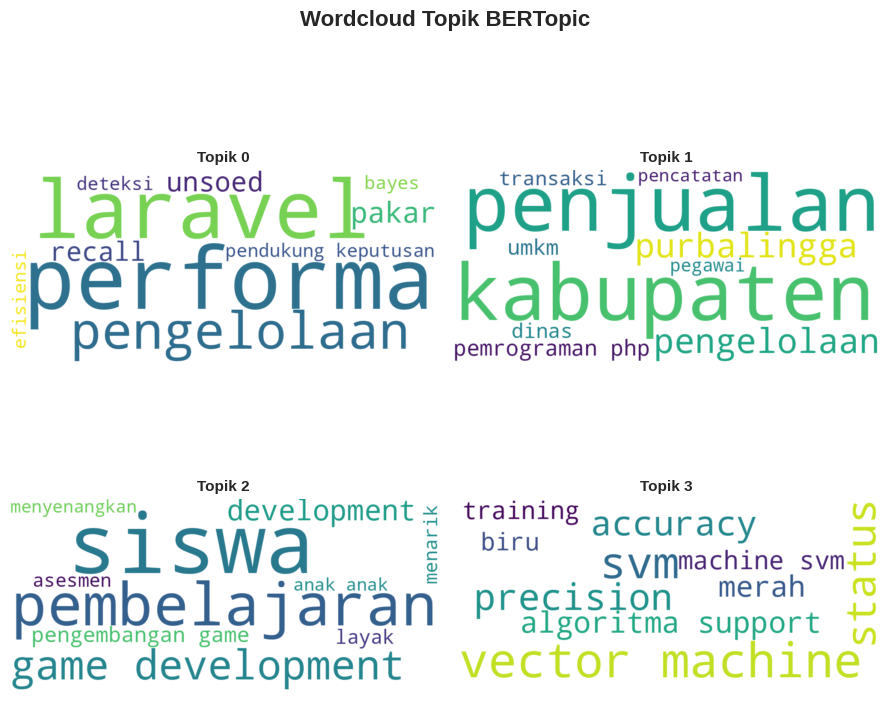

Wordcloud tersimpan: /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/figures/bertopic_wordcloud_topics_20260409-212006.png
DTM: menampilkan 4 topik dari total 4 topik.


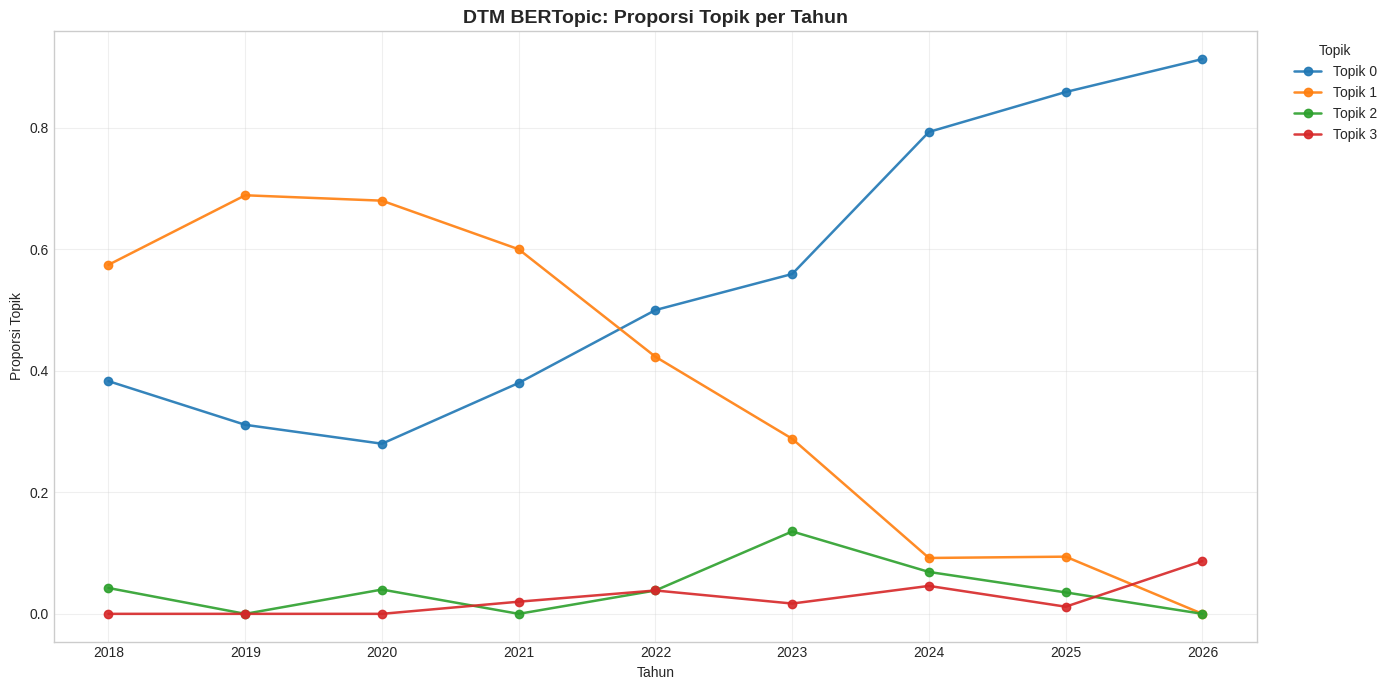

DTM plot tersimpan: /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/figures/bertopic_dtm_share_20260409-212006.png

Ringkasan trend topik BERTopic (berdasarkan share)


,Topic,start_share_pct,end_share_pct,delta_share_pct,slope
0,0,38.30,91.3,53.01,0.082815
1,3,0.00,8.7,8.70,0.007867
2,2,4.26,0.0,-4.26,0.002153
3,1,57.45,0.0,-57.45,-0.092836


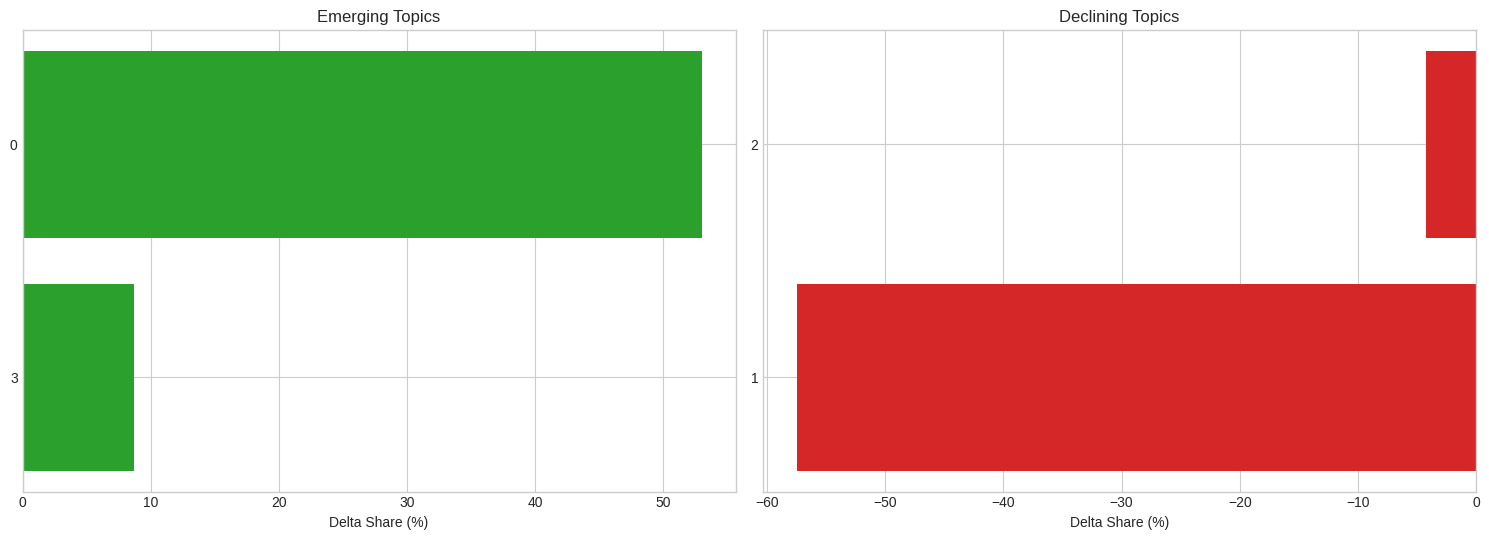

Emerging/Declining plot tersimpan: /home/galih/MySkripsi/- Aplikasi/my-skripsi/analysis/output/bertopic_tuning/figures/bertopic_emerging_declining_20260409-212006.png


In [14]:
# =========================================
# Visualisasi: Wordcloud, DTM, Emerging vs Declining Topic
# =========================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Atur jumlah topik yang ingin divisualisasikan.
# Set None untuk menampilkan semua topik valid.
MAX_WORDCLOUD_TOPICS = 18
MAX_DTM_TOPICS = 18
TOP_EMERGING_DECLINING = 8

try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except Exception as exc:
    HAS_WORDCLOUD = False
    print("Package 'wordcloud' belum tersedia. Install dengan: pip install wordcloud")
    print(f"Detail: {type(exc).__name__}: {exc}")

plt.style.use("seaborn-v0_8-whitegrid")
FIGURE_OUTPUT_DIR = OUTPUT_DIR / "figures"
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- 1) Wordcloud topik BERTopic ----------
best_topic_model = None
if "best_trainer_dta" in globals() and getattr(best_trainer_dta, "model", None) is not None:
    best_topic_model = best_trainer_dta.model

if best_topic_model is None:
    print("Model BERTopic best belum ada di memori. Jalankan Cell 11 terlebih dahulu.")
elif not HAS_WORDCLOUD:
    print("Wordcloud dilewati karena package belum tersedia.")
else:
    topic_info = best_topic_model.get_topic_info()
    all_topic_ids = topic_info.loc[topic_info["Topic"] != -1, "Topic"].astype(int).tolist()

    if MAX_WORDCLOUD_TOPICS is None:
        top_topic_ids = all_topic_ids
    else:
        top_topic_ids = all_topic_ids[: max(1, int(MAX_WORDCLOUD_TOPICS))]

    print(f"Wordcloud: menampilkan {len(top_topic_ids)} topik dari total {len(all_topic_ids)} topik.")

    if not top_topic_ids:
        print("Tidak ada topik valid untuk divisualisasikan.")
    else:
        n_topics = len(top_topic_ids)
        if n_topics <= 4:
            n_cols = 2
        elif n_topics <= 9:
            n_cols = 3
        else:
            n_cols = 4
        n_rows = int(np.ceil(n_topics / n_cols))

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4.2 * n_rows))
        axes = np.array(axes).reshape(-1)

        for idx, topic_id in enumerate(top_topic_ids):
            words_scores = best_topic_model.get_topic(topic_id) or []
            freq = {
                word: max(float(score), 1e-12)
                for word, score in words_scores[:40]
                if isinstance(word, str) and word.strip()
            }

            ax = axes[idx]
            if not freq:
                ax.set_title(f"Topik {topic_id} (kosong)")
                ax.axis("off")
                continue

            wc = WordCloud(
                width=1000,
                height=450,
                background_color="white",
                colormap="viridis",
                max_words=80,
                collocations=False,
            ).generate_from_frequencies(freq)

            ax.imshow(wc, interpolation="bilinear")
            ax.set_title(f"Topik {topic_id}", fontsize=11, fontweight="bold")
            ax.axis("off")

        for idx in range(n_topics, len(axes)):
            axes[idx].axis("off")

        plt.suptitle("Wordcloud Topik BERTopic", fontsize=16, fontweight="bold")
        plt.tight_layout()
        wordcloud_path = FIGURE_OUTPUT_DIR / f"bertopic_wordcloud_topics_{RUN_STAMP}.png"
        plt.savefig(wordcloud_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Wordcloud tersimpan: {wordcloud_path}")

# ---------- 2) DTM BERTopic + Emerging/Declining ----------
if "best_topics_over_time_df" not in globals() or best_topics_over_time_df.empty:
    print("Data DTM BERTopic belum tersedia. Jalankan Cell 11 dengan RUN_DTA_AFTER_BEST=True.")
else:
    dtm_df = best_topics_over_time_df.copy()
    required_cols = {"Timestamp", "Topic", "Frequency"}

    if not required_cols.issubset(set(dtm_df.columns)):
        print("Format topics_over_time tidak sesuai. Kolom yang ditemukan:", dtm_df.columns.tolist())
    else:
        dtm_df = dtm_df[dtm_df["Topic"] != -1].copy()
        dtm_df["Timestamp"] = pd.to_numeric(dtm_df["Timestamp"], errors="coerce")
        dtm_df["Topic"] = pd.to_numeric(dtm_df["Topic"], errors="coerce")
        dtm_df["Frequency"] = pd.to_numeric(dtm_df["Frequency"], errors="coerce")
        dtm_df = dtm_df.dropna(subset=["Timestamp", "Topic", "Frequency"]).copy()

        if dtm_df.empty:
            print("Data DTM kosong setelah pembersihan.")
        else:
            dtm_df["Timestamp"] = dtm_df["Timestamp"].astype(int)
            dtm_df["Topic"] = dtm_df["Topic"].astype(int)

            topic_totals = dtm_df.groupby("Topic")["Frequency"].sum().sort_values(ascending=False)
            if MAX_DTM_TOPICS is None:
                top_dtm_topics = topic_totals.index.tolist()
            else:
                top_dtm_topics = topic_totals.head(max(1, int(MAX_DTM_TOPICS))).index.tolist()

            print(f"DTM: menampilkan {len(top_dtm_topics)} topik dari total {topic_totals.shape[0]} topik.")
            dtm_plot_df = dtm_df[dtm_df["Topic"].isin(top_dtm_topics)].copy()

            freq_pivot = (
                dtm_plot_df.pivot_table(
                    index="Timestamp",
                    columns="Topic",
                    values="Frequency",
                    aggfunc="sum",
                    fill_value=0,
                )
                .sort_index()
            )

            share_pivot = freq_pivot.div(
                freq_pivot.sum(axis=1).replace(0, np.nan),
                axis=0,
            ).fillna(0.0)

            fig, ax = plt.subplots(figsize=(14, 7))
            for topic_id in share_pivot.columns:
                ax.plot(
                    share_pivot.index,
                    share_pivot[topic_id],
                    marker="o",
                    linewidth=1.8,
                    alpha=0.9,
                    label=f"Topik {topic_id}",
                )

            ax.set_title("DTM BERTopic: Proporsi Topik per Tahun", fontsize=14, fontweight="bold")
            ax.set_xlabel("Tahun")
            ax.set_ylabel("Proporsi Topik")
            legend_cols = 2 if len(share_pivot.columns) >= 10 else 1
            ax.legend(title="Topik", bbox_to_anchor=(1.02, 1), loc="upper left", ncol=legend_cols)
            ax.grid(alpha=0.3)
            plt.tight_layout()
            dtm_path = FIGURE_OUTPUT_DIR / f"bertopic_dtm_share_{RUN_STAMP}.png"
            plt.savefig(dtm_path, dpi=150, bbox_inches="tight")
            plt.show()
            print(f"DTM plot tersimpan: {dtm_path}")

            trend_rows = []
            for topic_id in share_pivot.columns:
                series = share_pivot[topic_id]
                if series.shape[0] < 2:
                    continue

                start_val = float(series.iloc[0])
                end_val = float(series.iloc[-1])
                delta_val = end_val - start_val

                x = np.arange(series.shape[0], dtype=float)
                slope = float(np.polyfit(x, series.values.astype(float), 1)[0])

                trend_rows.append(
                    {
                        "Topic": int(topic_id),
                        "start_share": start_val,
                        "end_share": end_val,
                        "delta_share": delta_val,
                        "slope": slope,
                    }
                )

            trend_df = pd.DataFrame(trend_rows).sort_values("delta_share", ascending=False).reset_index(drop=True)

            if trend_df.empty:
                print("Trend topik tidak bisa dihitung (data tahun terlalu sedikit).")
            else:
                trend_view_df = trend_df.copy()
                trend_view_df["start_share_pct"] = (trend_view_df["start_share"] * 100).round(2)
                trend_view_df["end_share_pct"] = (trend_view_df["end_share"] * 100).round(2)
                trend_view_df["delta_share_pct"] = (trend_view_df["delta_share"] * 100).round(2)
                display_step_table(
                    trend_view_df[["Topic", "start_share_pct", "end_share_pct", "delta_share_pct", "slope"]],
                    "Ringkasan trend topik BERTopic (berdasarkan share)",
                    preview_rows=20,
                )

                emerging_df = (
                    trend_df[trend_df["delta_share"] > 0]
                    .sort_values("delta_share", ascending=False)
                    .head(max(1, int(TOP_EMERGING_DECLINING)))
                    .sort_values("delta_share")
                )
                declining_df = (
                    trend_df[trend_df["delta_share"] < 0]
                    .sort_values("delta_share", ascending=True)
                    .head(max(1, int(TOP_EMERGING_DECLINING)))
                )

                fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

                if not emerging_df.empty:
                    axes[0].barh(
                        emerging_df["Topic"].astype(str),
                        emerging_df["delta_share"] * 100,
                        color="#2ca02c",
                    )
                    axes[0].set_title("Emerging Topics")
                    axes[0].set_xlabel("Delta Share (%)")
                else:
                    axes[0].text(0.5, 0.5, "Tidak ada topik emerging", ha="center", va="center")
                    axes[0].set_axis_off()

                if not declining_df.empty:
                    axes[1].barh(
                        declining_df["Topic"].astype(str),
                        declining_df["delta_share"] * 100,
                        color="#d62728",
                    )
                    axes[1].set_title("Declining Topics")
                    axes[1].set_xlabel("Delta Share (%)")
                else:
                    axes[1].text(0.5, 0.5, "Tidak ada topik declining", ha="center", va="center")
                    axes[1].set_axis_off()

                plt.tight_layout()
                trend_path = FIGURE_OUTPUT_DIR / f"bertopic_emerging_declining_{RUN_STAMP}.png"
                plt.savefig(trend_path, dpi=150, bbox_inches="tight")
                plt.show()
                print(f"Emerging/Declining plot tersimpan: {trend_path}")

## Cara pakai hasil ke Laravel

1. Jalankan sel BERTopic tuning lalu ambil file `bertopic_laravel_payload_*.json` dari folder output notebook.
2. Jalankan sel LDA tuning lalu ambil file `lda_laravel_payload_*.json` dari folder output notebook.
3. Copy nilai parameter ke form pengaturan BERTopic dan LDA di dashboard Laravel.
4. Jalankan preprocessing + training di website.
5. Gunakan tabel perbandingan model (CV & TD) untuk memilih model/parameter final.

Catatan DTA/DTM:
- Loop tuning BERTopic/LDA sekarang **tanpa** DTA agar proses cepat.
- DTA BERTopic (`topics_over_time`) dan topics-per-year LDA dijalankan **sekali** setelah best parameter ditemukan.

Semua tabel ringkas per step otomatis disimpan ke folder `analysis/output/bertopic_tuning/step_tables` dengan pola nama:
- `stepXX_nama_tahap_<RUN_STAMP>.csv`

Jika ingin eksplorasi lebih agresif untuk menambah jumlah topik:
- BERTopic: turunkan `min_topic_size`, kecilkan `hdbscan_min_cluster_size`, kecilkan `hdbscan_min_samples`, naikkan `umap_n_neighbors` bertahap.
- LDA: naikkan variasi `num_topics`, sesuaikan `alpha/eta`, dan uji kombinasi `no_below/no_above` untuk keseimbangan CV vs TD.